In [1]:
from jax import vmap

import Bivariate_Spline
import jax.numpy as jnp
import jax

import matplotlib.pyplot as plt
import pandas
# from mpl_toolkits.mplot3d import Axes3D

In [2]:
def create_clamped_knots(internal, degree=3):
    """
    Generates knots with 'clamped' boundaries (repeated start/end).
    Total knots = num_intervals + 2 * degree
    """
    # Pad with repeats
    # [0, 0, 0,  0, 0.1, ..., 3.14,  3.14, 3.14, 3.14]
    knots = jnp.concatenate([
        jnp.full(degree, internal[0]), 
        internal, 
        jnp.full(degree, internal[-1])
    ])
    return knots

In [35]:
degree = 3
x_knot = jnp.linspace(0, 3.15, 25)
y_knot = jnp.linspace(0, 3.15, 51)

# Generate Training Data
x, y = jnp.meshgrid(x_knot, y_knot)
my_function = vmap(lambda xx, yy: jnp.sin(xx) * jnp.cos(2*yy))
z = my_function(x,y)

# Fit
spline_predict = Bivariate_Spline.bivariate_spline_interp(z,x_knot, y_knot, degree = degree, regularization=1e-4)

In [36]:
# Create a PRNG key
key = jax.random.PRNGKey(0)

# Split the key into two new, independent sub-keys
k1, k2 = jax.random.split(key)

# Use k1 for x and k2 for y
test_x = jax.random.uniform(k1, (1000,), minval=0.01, maxval=3.14)
test_y = jax.random.uniform(k2, (1000,), minval=0.01, maxval=3.14)
# test_x = jnp.ravel(x)
# test_y = jnp.ravel(y)
test_z = my_function(test_x,test_y)

# Predict
z_predicted = spline_predict(test_x, test_y)



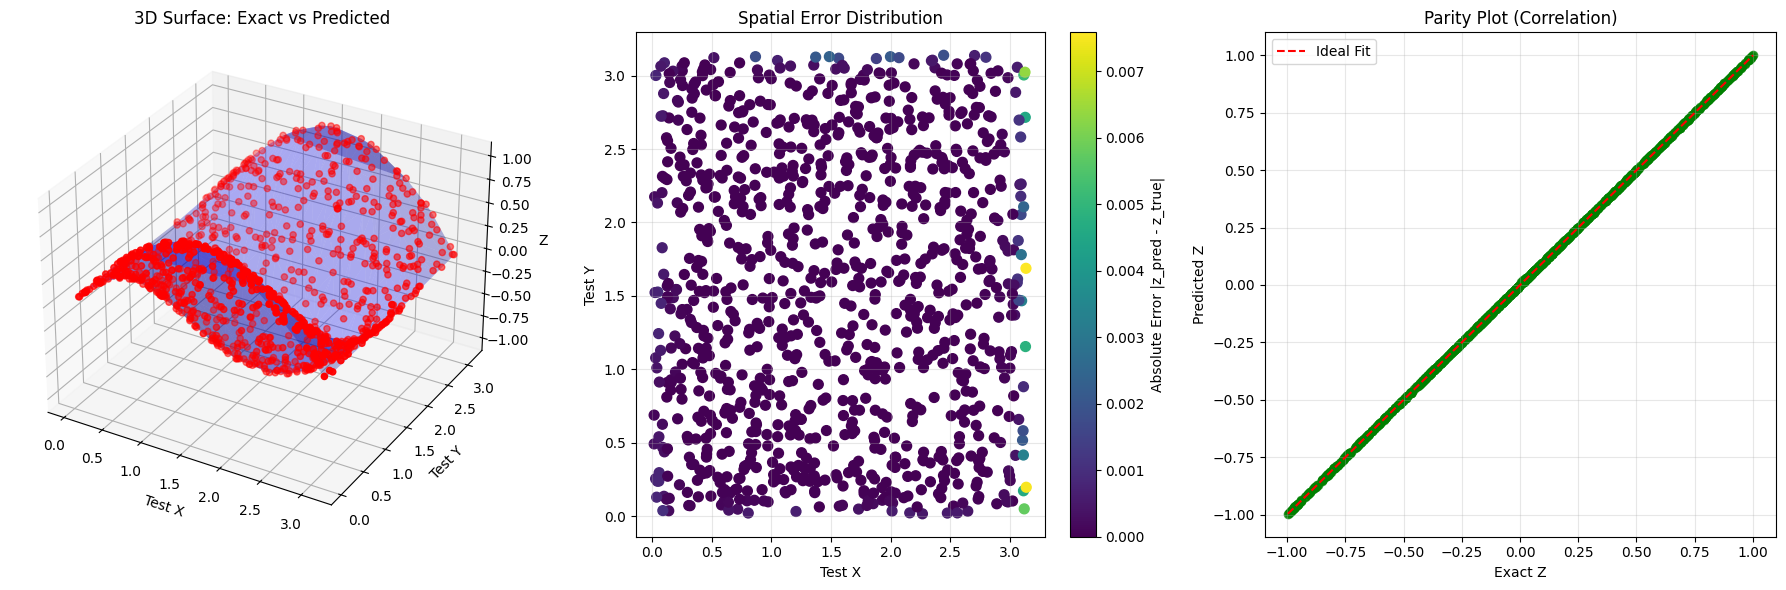

In [37]:
# Calculate the error
error = jnp.abs(z_predicted - test_z)

# Set up the figure
fig = plt.figure(figsize=(18, 6))

# --- Plot 1: 3D Comparison (using Triangulation for surface effect) ---
ax1 = fig.add_subplot(131, projection='3d')
# Plot exact surface (wireframe or trisurf)
ax1.plot_trisurf(test_x, test_y, test_z, color='blue', alpha=0.3, label='Exact')
# Plot predicted points
ax1.scatter(test_x, test_y, z_predicted, color='red', s=20, label='Predicted')
ax1.set_xlabel('Test X')
ax1.set_ylabel('Test Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Surface: Exact vs Predicted')

# --- Plot 2: 2D Error Map ---
# Scatter plot where color represents the magnitude of error
ax2 = fig.add_subplot(132)
sc = ax2.scatter(test_x, test_y, c=error, cmap='viridis', s=50)
plt.colorbar(sc, ax=ax2, label='Absolute Error |z_pred - z_true|')
ax2.set_xlabel('Test X')
ax2.set_ylabel('Test Y')
ax2.set_title('Spatial Error Distribution')
ax2.grid(True, alpha=0.3)

# --- Plot 3: Parity Plot (Predicted vs Exact) ---
ax3 = fig.add_subplot(133)
ax3.scatter(test_z, z_predicted, alpha=0.7, c='green')
# Draw the ideal y=x line
min_val = min(jnp.min(test_z), jnp.min(z_predicted))
max_val = max(jnp.max(test_z), jnp.max(z_predicted))
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit')
ax3.set_xlabel('Exact Z')
ax3.set_ylabel('Predicted Z')
ax3.set_title('Parity Plot (Correlation)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:

df = pandas.DataFrame({"test_x":test_x, "test_y":test_y, "z_predicted":z_predicted, "test_z":test_z, "Absolute Error |z_pred - z_true|": jnp.abs(z_predicted - test_z)})


Text(0.5, 0.92, '3D Surface: Predicted')

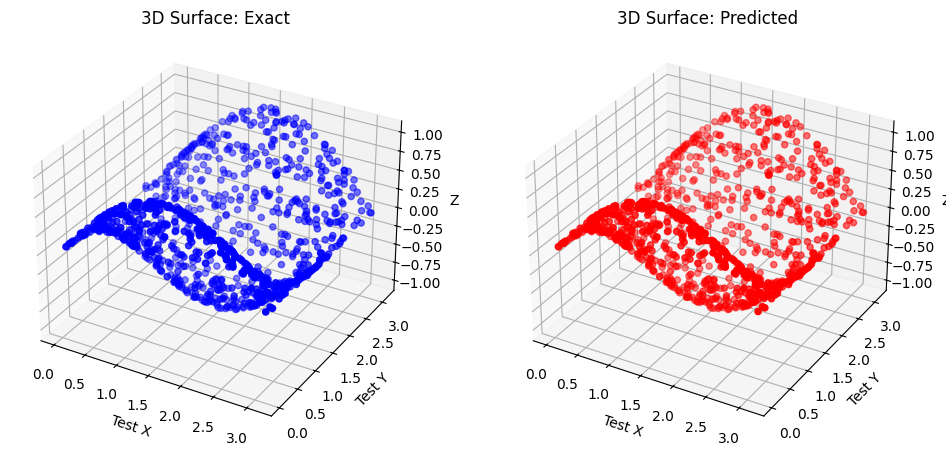

In [25]:
fig = plt.figure(figsize=(18, 6))

# --- Plot 1: 3D Comparison (using Triangulation for surface effect) ---
ax1 = fig.add_subplot(131, projection='3d')
# Plot exact surface (wireframe or trisurf)
ax1.scatter(test_x, test_y, test_z, color='blue', label='Exact')
# Plot predicted points
# ax2.scatter(test_x, test_y, z_predicted, color='red', s=20, label='Predicted')
ax1.set_xlabel('Test X')
ax1.set_ylabel('Test Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Surface: Exact')

# --- Plot 2: 2D Error Map ---
# Scatter plot where color represents the magnitude of error
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(test_x, test_y, z_predicted, color='red', label='Predicted')
ax2.set_xlabel('Test X')
ax2.set_ylabel('Test Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Surface: Predicted')

In [10]:

test_z_0 = my_function(x_knot,jnp.array([315.0]*len(x_knot)))

# Predict
z_predicted_0 = spline_predict(x_knot,jnp.array([315.0]*len(x_knot)))

In [11]:
pandas.DataFrame({"x":x_knot, "z":test_z_0,"z_in":z_predicted_0})

,x,z,z_in
0,0.00000,-0.000000,0.0
1,0.13125,-0.014455,0.0
2,0.26250,-0.028661,0.0
3,0.39375,-0.042374,0.0
4,0.52500,-0.055358,0.0
5,0.65625,-0.067389,0.0
6,0.78750,-0.078262,0.0
7,0.91875,-0.087788,0.0
8,1.05000,-0.095804,0.0
9,1.18125,-0.102173,0.0


In [12]:
jnp.sum(jnp.abs(z_predicted_0))/len(z_predicted_0)

Array(0., dtype=float32)

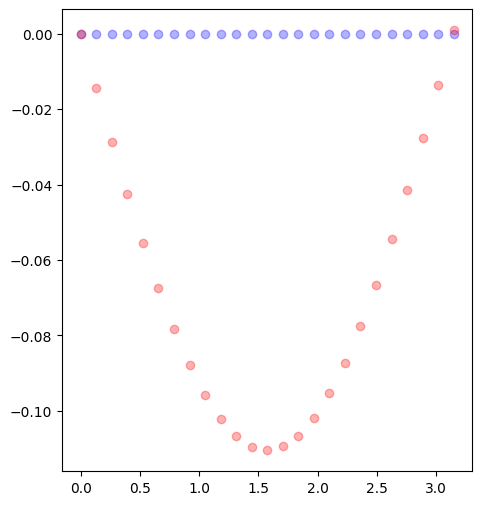

In [13]:
# Set up the figure
fig = plt.figure(figsize=(18, 6))

# --- Plot 1: 3D Comparison (using Triangulation for surface effect) ---
ax1 = fig.add_subplot(131)
# Plot exact surface (wireframe or trisurf)
ax1.scatter(x_knot, z_predicted_0, color='blue', alpha=0.3, label='Boundary')
# ax2 = fig.add_subplot(132)

ax1.scatter(x_knot, test_z_0, color='red', alpha=0.3, label='Boundary')
# ax2.scatter(x_knot, test_z_0/z_predicted_0, color='green', alpha=0.3, label='Boundary')

In [15]:
def fit(x, y, z, x_knots, y_knots, degree=3, regularization=1e-6, debug=False): #(x, y, z, x_knots, y_knots, degree, maxiter, regularization)
    x = jnp.ravel(x)
    y = jnp.ravel(y)
    z = jnp.ravel(z)

    n_basis_x = len(x_knots) - degree - 1
    n_basis_y = len(y_knots) - degree - 1
    if debug:
        print(f'number of x knots {len(x_knots)}, number of y knots {len(y_knots)}, z shape is {jnp.shape(z)}')
        print(f'number of x basis{n_basis_x}, number of y basis{n_basis_y}.')
    def build_row(xi, yi):
        # We must pass degree here. Since this helper is inside 'fit' (Python side),
        # it will unroll correctly when passed to vmap.
        bx = vmap(lambda k: Bivariate_Spline._bspline_basis(xi, k, x_knots, degree))(jnp.arange(n_basis_x))
        by = vmap(lambda k: Bivariate_Spline._bspline_basis(yi, k, y_knots, degree))(jnp.arange(n_basis_y))
        return jnp.outer(bx, by).flatten()

    A = vmap(build_row)(x, y)
    if debug:
        print(f"A shape: {A.shape}")
    lhs = A.T @ A + regularization * jnp.eye(A.shape[1])
    rhs = A.T @ z

    coeffs_flat = jnp.linalg.solve(lhs, rhs)
    coeffs = coeffs_flat.reshape(n_basis_x, n_basis_y)
    if debug:
        print(f"Fit complete. Coeffs shape: {coeffs.shape}")
    return coeffs
        

In [16]:
degree = 3
x_knots = Bivariate_Spline.create_clamped_knots(jnp.linspace(0, 3.15, 25), degree = degree)
y_knots = Bivariate_Spline.create_clamped_knots(jnp.linspace(0, 3.15, 51), degree = degree)

# Generate Training Data
x, y = jnp.meshgrid(x_knots, y_knots)
my_function = vmap(lambda xx, yy: jnp.sin(xx) * jnp.cos(2*yy))
z = my_function(x,y)

# Fit current
coeff_current = Bivariate_Spline._fit_solver_kernel(x, y, z, x_knots, y_knots, maxiter=5000, degree = degree, regularization=1e-10)
# Fit simple

coeff_simple = fit(x, y, z, x_knot, y_knot, degree = degree, regularization=1e-10,debug=True)

number of x knots 25, number of y knots 51, z shape is (1767,)
number of x basis21, number of y basis47.
A shape: (1767, 987)
Fit complete. Coeffs shape: (21, 47)


In [17]:
# pandas.DataFrame({'current':jnp.ravel(coeff_current),'simple':coeff_simple})

In [18]:
[coeff_current.shape, coeff_simple.shape]

[(27, 53), (21, 47)]

In [19]:
coeff_current - coeff_simple

TypeError: sub got incompatible shapes for broadcasting: (27, 53), (21, 47).

In [ ]:
[Bivariate_Spline._bspline_basis(x_knots[0], k=k, knots=x_knots, degree=3) for k in range(0,5)]

In [ ]:
[Bivariate_Spline._bspline_basis(x_knots[-1], k=k, knots=x_knots, degree=0) for k in range(x_knots.shape[0]-1-5,x_knots.shape[0]-1)]